<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Bootstrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**NOMBRE: FLORENCIO FLORENCIO MIRIAM LLIZETH**

<span style="color:blue;"> **Objetivo:**</span> El objetivo de este ejercicio es utilizar la técnica de Bootstrap para analizar la variabilidad de la media de los tiempos de entrega a partir de una muestra de 12 observaciones. Para ello, se generan 1000 remuestras con reemplazo de la muestra original, obteniendo así una distribución empírica de las medias. Con esta información es posible estimar el error estándar de la media y construir un intervalo de confianza del 95%, todo ello sin necesidad de asumir una distribución teórica específica para los datos observados

#  <span style="color:purple;">**Bootstrap**</span>

**Suponga que $X_1,\ldots,X_n$ son variables aleatorias independientes
con una función de distribución común $F$.**

**Queremos estimar $\theta(F)$ mediante el estimador**

$$
g(X_1,\ldots,X_n).
$$

**Entonces,**

$$
ECM(F)
=
\mathbb{E}_F
\left[
\bigl(
g(X_1,\ldots,X_n)-\theta(F)
\bigr)^2
\right].
$$

**Estimaremos $F$ con**

$$
F_e(x)
=
\frac{\#\{\,i : X_i \le x\,\}}{n},
$$

**donde $F_e(x)$ es la **distribución empírica**.**





### <span style="color:magenta;">**EJEMPLO**</span>

Esta es una muestra aleatoria de 12 tiempos de entrega:

$$
35,\;42,\;38,\;40,\;45,\;37,\;39,\;41,\;44,\;36,\;43,\;40
$$

**Instrucciones**

* Use la muestra original de 12 observaciones y genere
    1000 muestras Bootstrap a partir de $F_e(x)$.

* Para cada muestra Bootstrap, calcule la media.
* Al final:
    *  Obtenga la media de las 1000 medias.
    *  Calcule la desviación estándar.
    *  Determine los percentiles $2.5\%$ y $97.5\%$ para construir un intervalo de confianza Bootstrap del $95\%$.


In [5]:
# Bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import random

In [6]:

# Muestra original de tiempos de entrega
muestra_original = np.array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])

In [7]:


# Tamaño de la muestra original
n = len(muestra_original)

# Número de muestras Bootstrap
B = 1000

# Para que los resultados sean reproducibles
np.random.seed(123)

# Aquí guardaremos la media de cada muestra Bootstrap
medias_bootstrap = []


In [8]:
# ==============================
# Generación de muestras Bootstrap
# ==============================

for i in range(B):

    # Generamos una muestra Bootstrap:
    # se eligen n datos de la muestra original CON reemplazo
    muestra_bootstrap = np.random.choice(
        muestra_original,  # datos de donde se toma la muestra
        size=n,            # mismo tamaño que la muestra original
        replace=True       # con reemplazo
    )

    # Calculamos la media de la muestra Bootstrap
    media = np.mean(muestra_bootstrap)

    # Guardamos esa media
    medias_bootstrap.append(media)

# Convertimos la lista a arreglo de NumPy para facilitar cálculos
medias_bootstrap = np.array(medias_bootstrap)

In [9]:

# ==============================
# Resultados finales
# ==============================

# Media de las 1000 medias Bootstrap
media_de_medias = np.mean(medias_bootstrap)

# Desviación estándar de las medias Bootstrap
desviacion_estandar = np.std(medias_bootstrap, ddof=1)

# Percentiles para intervalo de confianza Bootstrap del 95%
percentil_2_5 = np.percentile(medias_bootstrap, 2.5)
percentil_97_5 = np.percentile(medias_bootstrap, 97.5)

# Media de la muestra original
media_original = np.mean(muestra_original)


In [10]:
# Desviación estándar Bootstrap
error_boot = np.std(
    medias_bootstrap,
    ddof=1
)


In [11]:
error_boot

np.float64(0.8652799408530799)

In [12]:


# ==============================
# Mostrar resultados
# ==============================

print("Media de la muestra original:", media_original)
print("Media de las 1000 medias Bootstrap:", media_de_medias)
print("Desviación estándar Bootstrap:", desviacion_estandar)
print("Percentil 2.5%:", percentil_2_5)
print("Percentil 97.5%:", percentil_97_5)

print("\nIntervalo de confianza Bootstrap del 95%:")
print(f"({percentil_2_5}, {percentil_97_5})")

Media de la muestra original: 40.0
Media de las 1000 medias Bootstrap: 40.009
Desviación estándar Bootstrap: 0.8652799408530799
Percentil 2.5%: 38.416666666666664
Percentil 97.5%: 41.666666666666664

Intervalo de confianza Bootstrap del 95%:
(38.416666666666664, 41.666666666666664)


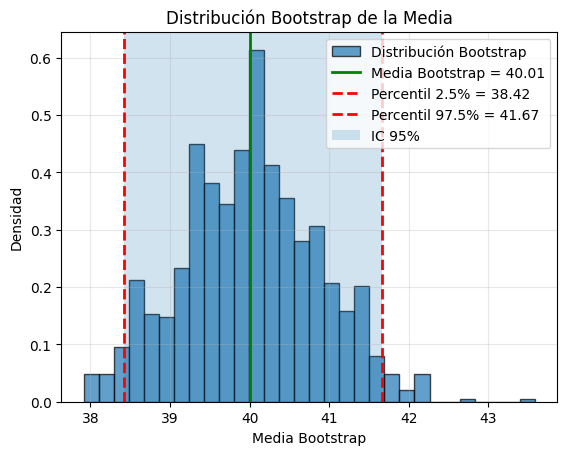

In [13]:


# Histograma
plt.hist(
    medias_bootstrap,
    bins=30,
    density=True,
    edgecolor='black',
    alpha=0.7,
    label='Distribución Bootstrap'
)

# Media Bootstrap
plt.axvline(
    media_de_medias,
    color='green',
    linestyle='-',
    linewidth=2,
    label=f'Media Bootstrap = {media_de_medias:.2f}'
)

# Percentil 2.5%
plt.axvline(
    percentil_2_5,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Percentil 2.5% = {percentil_2_5:.2f}'
)

# Percentil 97.5%
plt.axvline(
    percentil_97_5,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Percentil 97.5% = {percentil_97_5:.2f}'
)

# Región del intervalo de confianza
plt.axvspan(
    percentil_2_5,
    percentil_97_5,
    alpha=0.2,
    label='IC 95%'
)

plt.title('Distribución Bootstrap de la Media')
plt.xlabel('Media Bootstrap')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### <span style="color:teal;">**Solución Analítica** (libro de Ross)</span>


Considérese la siguiente muestra de $12$ tiempos de entrega:

$$
35,\;42,\;38,\;40,\;45,\;37,\;39,\;41,\;44,\;36,\;43,\;40.
$$

El objetivo es estimar la media poblacional mediante el método \textbf{Bootstrap} y construir un intervalo de confianza del $95\%$ para dicha media.

**1. Cálculo de la media muestral**

La media de la muestra observada se calcula mediante

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i,
$$

donde $n=12$.

Sustituyendo los valores observados:

$$
\bar{x}
=
\frac{35+42+38+40+45+37+39+41+44+36+43+40}{12}.
$$

Como la suma de los datos es

$$
35+42+38+40+45+37+39+41+44+36+43+40=480,
$$

se obtiene
$$
\bar{x}
=
\frac{480}{12}
=
40.
$$

Por lo tanto,

$$
\boxed{\bar{x}=40}.
$$

**2. Distribución empírica Bootstrap**

En el procedimiento Bootstrap se considera que la muestra observada representa a la población. Por ello, cada observación tiene la misma probabilidad de ser seleccionada en una remuestra:

$$
P(X^{*}=x_i)=\frac{1}{12},
\qquad
i=1,\ldots,12.
$$

Esta distribución se conoce como la **distribución empírica Bootstrap**.

**3. Esperanza de una observación Bootstrap**

El valor esperado de una observación obtenida mediante Bootstrap es

$$
E(X^{*})
=
\sum_{i=1}^{12}
x_i\,P(X^{*}=x_i).
$$

Como todas las probabilidades son iguales a $\frac{1}{12}$,

$$
E(X^{*})
=
\frac{1}{12}
\sum_{i=1}^{12}x_i.
$$

Sustituyendo la suma de los datos:

$$
E(X^{*})
=
\frac{480}{12}
=
40.
$$

Por lo tanto,

$$
\boxed{E(X^{*})=40}.
$$

Esto muestra que la distribución Bootstrap está centrada en la media muestral observada.

**4. Varianza de la distribución empírica**

Para medir la dispersión de los datos se calculan primero las desviaciones respecto a la media:

$$
\begin{aligned}
\sum_{i=1}^{12}(x_i-\bar{x})^2
&=
(35-40)^2+(42-40)^2+(38-40)^2+(40-40)^2 \\
&\quad +(45-40)^2+(37-40)^2+(39-40)^2+(41-40)^2 \\
&\quad +(44-40)^2+(36-40)^2+(43-40)^2+(40-40)^2.
\end{aligned}
$$

Es decir,

$$
\sum_{i=1}^{12}(x_i-\bar{x})^2
=
25+4+4+0+25+9+1+1+16+16+9+0
=
110.
$$

La varianza de una observación Bootstrap es

$$
\mathrm{Var}(X^{*})
=
\frac{1}{12}
\sum_{i=1}^{12}(x_i-\bar{x})^2.
$$

Por lo tanto,

$$
\mathrm{Var}(X^{*})
=
\frac{110}{12}
=
9.1667.
$$

Así,

$$
\boxed{\mathrm{Var}(X^{*})=9.1667}.
$$

**5. Distribución de la media Bootstrap**

Sea
$$
\bar{X}^{*}
=
\frac{1}{12}
\sum_{j=1}^{12}
X_j^{*}
$$

la media obtenida a partir de una remuestra Bootstrap de tamaño $12$.

Por linealidad de la esperanza,

$$
E(\bar{X}^{*})
=
E(X^{*})
=
40.
$$

Además, como las observaciones remuestreadas son independientes,

$$
\mathrm{Var}(\bar{X}^{*})
=
\frac{\mathrm{Var}(X^{*})}{12}.
$$

Sustituyendo el valor calculado anteriormente,

$$
\mathrm{Var}(\bar{X}^{*})
=
\frac{9.1667}{12}
=
0.7639.
$$

Por consiguiente, la desviación estándar de la media Bootstrap es

$$
\sigma_{\bar{X}^{*}}
=
\sqrt{0.7639}
=
0.874.
$$

Por lo tanto,

$$
\boxed{\sigma_{\bar{X}^{*}}\approx0.874}.
$$

Este valor corresponde al error estándar de la estimación Bootstrap.

**6. Construcción del intervalo de confianza del $95\%$**

Bajo una aproximación normal, un intervalo de confianza bilateral del $95\%$ para la media se construye mediante

$$
\bar{x}
\pm
z_{0.975}\sigma_{\bar{X}^{*}},
$$
donde

$$
z_{0.975}=1.96.
$$

Sustituyendo los valores obtenidos:

$$
40\pm1.96(0.874).
$$

Calculando el margen de error,

$$
1.96(0.874)=1.713.
$$

Así,
$$
40\pm1.713.
$$

Por lo tanto,

$$
IC_{95\%}
=
(40-1.713,\;40+1.713).
$$

Finalmente,

$$
\boxed{
IC_{95\%}
=
(38.287,\;41.713)
}.
$$

Redondeando a dos decimales,

$$
\boxed{
IC_{95\%}
\approx
(38.29,\;41.71)
}.
$$

**7. Interpretación de los resultados**

Los cálculos realizados muestran que la distribución Bootstrap está centrada en la media observada,

$$
E(\bar{X}^{*})=40,
$$

y presenta un error estándar aproximado de

$$
\sigma_{\bar{X}^{*}}=0.874.
$$

Además, el intervalo de confianza obtenido indica que, con un nivel de confianza del $95\%$, la media poblacional de los tiempos de entrega se encuentra aproximadamente entre

$$
38.29
\quad \text{y} \quad
41.71.
$$

La amplitud relativamente pequeña de este intervalo refleja una variabilidad moderada en los datos y una buena precisión en la estimación de la media. En consecuencia, los resultados obtenidos mediante simulación Bootstrap deberían ser muy cercanos a los valores analíticos calculados anteriormente.

# <span style="color:purple;"> **Conclusión** </span>


La aplicación del método Bootstrap permitió estimar la variabilidad de la media a partir de la información disponible en la muestra, sin necesidad de asumir una distribución específica para los datos. Mediante la generación de $1000$ remuestras, se construyó una distribución empírica de las medias, a partir de la cual fue posible calcular el error estándar y obtener un intervalo de confianza del $95\%$ para la media poblacional.

Los resultados muestran que la media estimada es estable y que el intervalo de confianza obtenido es relativamente estrecho, lo que indica una buena precisión en la estimación. En términos prácticos, esto significa que los tiempos de entrega observados proporcionan evidencia suficiente para afirmar que la media poblacional se encuentra dentro del rango calculado con un alto nivel de confianza.

Además, este ejercicio permite apreciar una de las principales ventajas del Bootstrap: obtener información sobre la incertidumbre de un estimador utilizando únicamente los datos observados. Gracias a esta característica, el método se convierte en una herramienta muy valiosa cuando se dispone de muestras pequeñas o cuando la distribución de la población es desconocida.

En conclusión, el procedimiento Bootstrap proporcionó una estimación confiable de la media y de su variabilidad, permitiendo cuantificar de manera sencilla la precisión de los resultados y reforzando la confianza en las inferencias realizadas a partir de la muestra analizada.